In [15]:
!pip install ucimlrepo xgboost shap lightgbm

In [16]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo

# Charger la data directement depuis UCI
dataset = fetch_ucirepo(id=544)
df_original = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
df = df_original.copy()

# AVANT
print("=" * 50)
print("AVANT — Data originale")
print("=" * 50)
print(df[['Gender', 'SMOKE', 'CAEC', 'NObeyesdad']].head(3))
print(f"\nTypes : \n{df[['Gender', 'SMOKE', 'CAEC', 'NObeyesdad']].dtypes}")

# ENCODAGE
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

le = LabelEncoder()
for col in ['Gender', 'CAEC', 'CALC', 'MTRANS']:
    df[col] = le.fit_transform(df[col])

le_target = LabelEncoder()
df['NObeyesdad'] = le_target.fit_transform(df['NObeyesdad'])

# APRÈS
print("\n" + "=" * 50)
print("APRÈS — Data encodée")
print("=" * 50)
print(df[['Gender', 'SMOKE', 'CAEC', 'NObeyesdad']].head(3))
print(f"\nTypes : \n{df[['Gender', 'SMOKE', 'CAEC', 'NObeyesdad']].dtypes}")

# MÉMOIRE
def optimize_memory(df):
    before = df.memory_usage(deep=True).sum() / 1024
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype('float32')
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = df[col].astype('int32')
    after = df.memory_usage(deep=True).sum() / 1024
    print(f"\n{'='*50}")
    print("OPTIMISATION MÉMOIRE")
    print(f"{'='*50}")
    print(f"Avant  : {before:.1f} KB")
    print(f"Après  : {after:.1f} KB")
    print(f"Gagné  : {((before-after)/before*100):.1f}%")
    return df

df = optimize_memory(df)

# SPLIT
X = df.drop(columns=['NObeyesdad'])
y = df['NObeyesdad']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n{'='*50}")
print("SÉPARATION TRAIN / TEST")
print(f"{'='*50}")
print(f"Total lignes    : {len(df)}")
print(f"Train (80%)     : {X_train.shape[0]} lignes")
print(f"Test  (20%)     : {X_test.shape[0]} lignes")
print(f"\n✅ Data prête pour le ML !")

AVANT — Data originale
   Gender SMOKE       CAEC     NObeyesdad
0  Female    no  Sometimes  Normal_Weight
1  Female   yes  Sometimes  Normal_Weight
2    Male    no  Sometimes  Normal_Weight

Types : 
Gender        object
SMOKE         object
CAEC          object
NObeyesdad    object
dtype: object

APRÈS — Data encodée
   Gender  SMOKE  CAEC  NObeyesdad
0       0      0     2           1
1       0      1     2           1
2       1      0     2           1

Types : 
Gender        int64
SMOKE         int64
CAEC          int64
NObeyesdad    int64
dtype: object

OPTIMISATION MÉMOIRE
Avant  : 280.5 KB
Après  : 140.3 KB
Gagné  : 50.0%

SÉPARATION TRAIN / TEST
Total lignes    : 2111
Train (80%)     : 1688 lignes
Test  (20%)     : 423 lignes

✅ Data prête pour le ML !


In [17]:
df.head(20)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.0,1.62,64.000000,1,0,2.0,3.0,2,0,2.0,0,0.0,1.0,3,3,1
1,0,21.0,1.52,56.000000,1,0,3.0,3.0,2,1,3.0,1,3.0,0.0,2,3,1
2,1,23.0,1.80,77.000000,1,0,2.0,3.0,2,0,2.0,0,2.0,1.0,1,3,1
3,1,27.0,1.80,87.000000,0,0,3.0,3.0,2,0,2.0,0,2.0,0.0,1,4,5
4,1,22.0,1.78,89.800003,0,0,2.0,1.0,2,0,2.0,0,0.0,0.0,2,3,6
5,1,29.0,1.62,53.000000,0,1,2.0,3.0,2,0,2.0,0,0.0,0.0,2,0,1
6,0,23.0,1.50,55.000000,1,1,3.0,3.0,2,0,2.0,0,1.0,0.0,2,2,1
7,1,22.0,1.64,53.000000,0,0,2.0,3.0,2,0,2.0,0,3.0,0.0,2,3,1
8,1,24.0,1.78,64.000000,1,1,3.0,3.0,2,0,2.0,0,1.0,1.0,1,3,1
9,1,22.0,1.72,68.000000,1,1,2.0,3.0,2,0,2.0,0,1.0,1.0,3,3,1


In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

Accuracy : 95.74%
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        56
           1       0.95      0.85      0.90        62
           2       0.97      0.96      0.97        78
           3       0.97      0.97      0.97        58
           4       1.00      1.00      1.00        63
           5       0.88      0.95      0.91        56
           6       1.00      0.98      0.99        50

    accuracy                           0.96       423
   macro avg       0.96      0.96      0.96       423
weighted avg       0.96      0.96      0.96       423



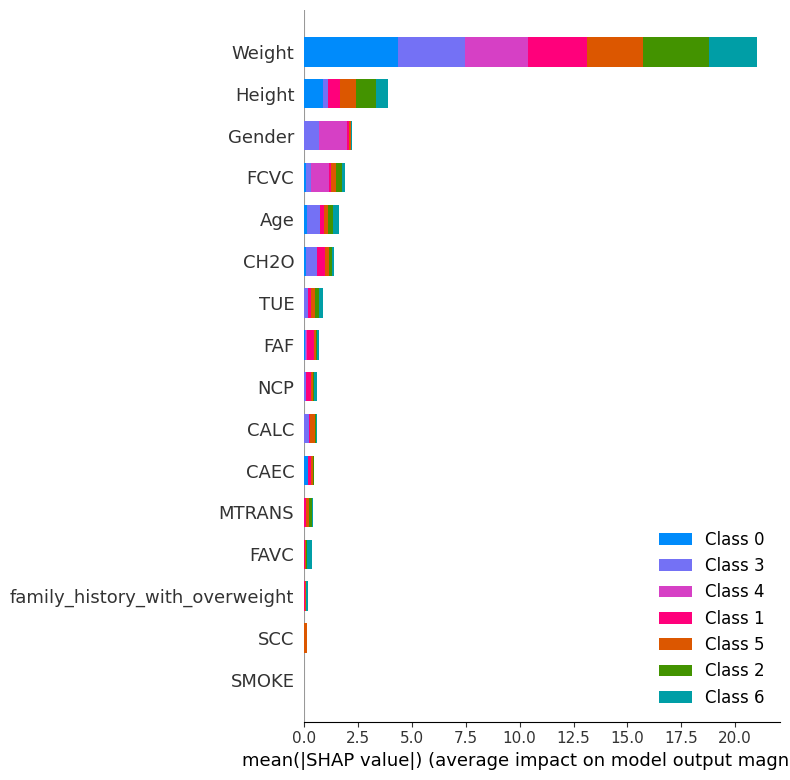

In [19]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Graphique : features les plus importantes
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [21]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

from google.colab import files
files.download("model.pkl")
print("✅ Modèle téléchargé !")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Modèle téléchargé !
